# 공공 IT사업 입찰 공고 데이터 EDA
## RAG 시스템 구축을 위한 탐색적 데이터 분석

---

## EDA 진행 계획

### 1단계: 데이터 품질 점검
| 분석 | 효과 |
|------|------|
| **결측치 분석** — 공고번호(18), 입찰시작일(26), 마감일(8), 금액(1) | 데이터 신뢰도 파악 및 결측 패턴 확인 (MCAR/MAR 여부). 이후 분석에서 제외할지 대체할지 전략 결정 |
| **중복 확인** — 사업명 99 unique (100행 중) | 동일 사업의 차수별 중복 공고 여부 파악 |
| **이상치 탐지** — 사업금액 (min=0, max=141억, 중앙값=1.7억) | 금액 0원인 건, 극단적 고액 건 식별 → 분석 왜곡 방지 |
| **날짜 포맷 통일** — 공개일자·시작일·마감일을 datetime 변환 | 시계열 분석 가능하게 만들고, 파싱 실패 건 확인 |

### 2단계: 기술 통계 & 분포 분석
| 분석 | 효과 |
|------|------|
| **사업 금액 분포** — 히스토그램 + boxplot | 공공 IT사업 예산 규모 분포 파악, 소규모/대규모 사업 비율 확인 |
| **발주 기관 분포** — 상위 기관 bar chart | 어떤 기관이 IT사업을 많이 발주하는지, 시장 집중도 파악 |
| **시계열 트렌드** — 월별 공고 건수 추이 | 공고가 집중되는 시기(분기말 등) 파악 → 입찰 전략 수립 가능 |
| **입찰 기간 분석** — (마감일-시작일) 분포 | 평균 입찰 준비 기간 파악 → 긴급 공고 vs 일반 공고 구분 |

### 3단계: 텍스트 분석 (RAG 핵심)
| 분석 | 효과 |
|------|------|
| **텍스트 길이 분포** — 히스토그램 + 기술통계 | 청킹(chunking) 전략 결정의 기준. 89자~18,335자 편차가 크므로 고정 길이 vs 의미 단위 분할 선택에 직접 영향 |
| **텍스트 품질 점검** — 깨진 문자, 무의미 공백, 특수문자 비율, 머리글/꼬리글 반복 패턴 | hwp/pdf 변환 과정에서 생긴 노이즈가 그대로 임베딩되면 검색 정확도 하락 → 전처리 범위 결정 |
| **문서 구조 패턴** — 목차, 섹션 헤더(Ⅰ,Ⅱ,1.,2.), 표 구분자 등의 존재 비율 | 섹션 단위 청킹 가능 여부 판단 및 메타데이터로 활용할 구조적 요소 식별 |
| **핵심 키워드/용어 빈도** — 형태소 분석 기반 n-gram 추출 | 사용자 쿼리에 자주 등장할 도메인 용어 파악 → 임베딩 모델 선택 및 검색 쿼리 튜닝 기준 |
| **사업명/요약 워드클라우드** | 전체 공고의 핵심 주제를 시각적으로 한눈에 파악 → 사업 유형 카테고리 설계 기반 |
| **문서 간 유사도/중복 분석** — TF-IDF 기반 코사인 유사도 매트릭스 | 중복 콘텐츠가 검색 시 동일 내용 반복 반환하는 문제 사전 파악 → 중복 제거 또는 가중치 조정 필요성 판단 |
| **텍스트 길이 vs 사업금액 상관관계** | 제안요청서 분량이 사업 규모와 관련 있는지 확인 → 청킹 시 문서 메타데이터 활용 전략 수립 |

### 4단계: 교차 분석
| 분석 | 효과 |
|------|------|
| **기관 유형별 평균 사업금액** — 공공기관/대학/지자체 등 그룹화 | 기관 종류에 따른 예산 규모 차이 파악 |
| **재공고(공고 차수 > 0) 특성 분석** | 유찰되는 사업의 특징(금액, 기관, 기간) 파악 |
| **금액 구간별 사업 특성** | 소규모(<1억)/중규모(1~5억)/대규모(>5억) 사업 간 차이 비교 |

---
## 라이브러리 로드 및 데이터 읽기

분석에 필요한 라이브러리를 임포트하고, `data_list.csv`를 DataFrame으로 로드한다.  
- `utf-8-sig` 인코딩으로 BOM 제거  
- 로드 후 shape, 컬럼명, 상위 5행을 출력하여 데이터가 정상적으로 읽혔는지 확인한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('data_list.csv', encoding='utf-8-sig')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (100, 12)

Columns: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트']

Dtypes:
공고 번호            str
공고 차수        float64
사업명              str
사업 금액        float64
발주 기관            str
공개 일자            str
입찰 참여 시작일        str
입찰 참여 마감일        str
사업 요약            str
파일형식             str
파일명              str
텍스트              str
dtype: object


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...
3,20240430918,0.0,도시계획위원회 통합관리시스템 구축용역,150000000.0,인천광역시,2024-04-18 16:26:32,2024-05-02 10:00:00,2024-05-09 16:00:00,- 사업명: 도시계획위원회 통합관리시스템 구축 용역\n- 용역개요: 도시계획위원회와...,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,\r\n \r\n \r\n도시계획위원회 통합관리시스템 구축\r\n제 안 요 청...
4,20240430896,0.0,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),900000000.0,경상북도 봉화군,2024-04-18 16:33:28,2024-04-26 09:00:00,2024-04-30 17:00:00,- 사업명: 봉화군 재난통합관리시스템 고도화 사업\n- 사업개요: 공동수급(공동이행...,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,\r\n \r\n \r\n제안요청서\r\n \r\n사 업 명\r\n봉화...


---
# 1단계: 데이터 품질 점검

## 1-1. 결측치 분석

각 컬럼별 결측치 수와 비율을 확인한다.  
- 결측이 집중된 컬럼을 파악하여 MCAR(완전 무작위 결측) vs MAR(조건부 결측) 여부를 판단한다.  
- 결측 비율이 높은 컬럼(입찰 참여 시작일 등)은 분석 시 제외하거나 별도 처리 전략을 세운다.  
- **기대 결과**: 결측치 히트맵과 컬럼별 결측 비율 테이블

=== 결측치 현황 ===
           결측 수  결측 비율(%)
입찰 참여 시작일    26      26.0
공고 번호        18      18.0
공고 차수        18      18.0
입찰 참여 마감일     8       8.0
사업 금액         1       1.0

전체 행 수: 100


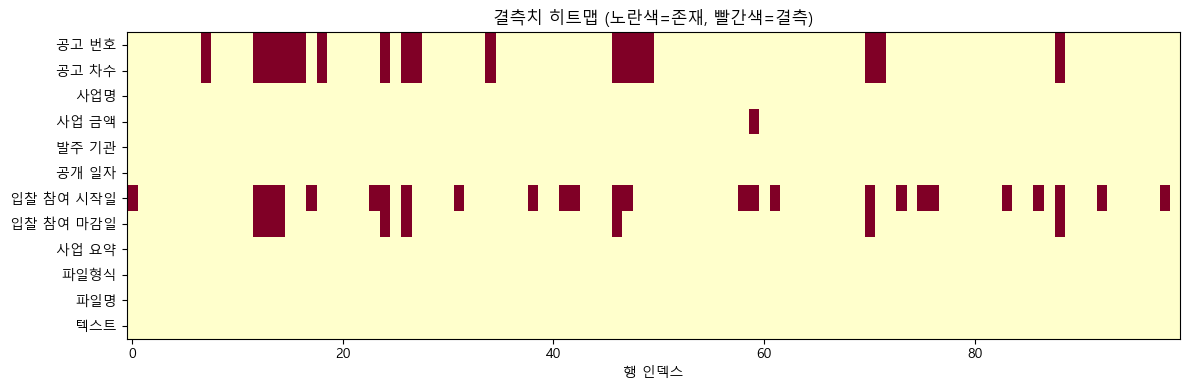

In [2]:
# 1-1. 결측치 분석
missing = pd.DataFrame({
    '결측 수': df.isnull().sum(),
    '결측 비율(%)': (df.isnull().sum() / len(df) * 100).round(1)
})
missing = missing[missing['결측 수'] > 0].sort_values('결측 수', ascending=False)
print("=== 결측치 현황 ===")
print(missing)
print(f"\n전체 행 수: {len(df)}")

# 결측치 히트맵
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(df.isnull().T, aspect='auto', cmap='YlOrRd', interpolation='none')
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns)
ax.set_xlabel('행 인덱스')
ax.set_title('결측치 히트맵 (노란색=존재, 빨간색=결측)')
plt.tight_layout()
plt.show()

## 1-2. 중복 확인

사업명 기준으로 중복된 행이 있는지 확인한다.  
- 동일 사업이 공고 차수(0차, 1차, 2차)로 여러 번 등록된 경우를 식별한다.  
- 중복 행이 존재하면 RAG 인덱싱 시 동일 문서가 중복 검색되는 문제를 사전에 파악할 수 있다.  
- **기대 결과**: 중복 사업명 목록과 해당 행의 공고 차수 비교

In [3]:
# 1-2. 중복 확인
dup_names = df[df.duplicated(subset='사업명', keep=False)]
print(f"=== 중복 사업명 ===")
print(f"전체 사업명: {df['사업명'].nunique()} unique / {len(df)} rows\n")

if len(dup_names) > 0:
    print("중복된 사업:")
    print(dup_names[['사업명', '공고 차수', '발주 기관', '사업 금액', '공개 일자']].to_string())
else:
    print("완전히 동일한 사업명은 없음")

# 공고 차수 분포
print(f"\n=== 공고 차수 분포 ===")
print(df['공고 차수'].value_counts(dropna=False).sort_index())

=== 중복 사업명 ===
전체 사업명: 99 unique / 100 rows

중복된 사업:
               사업명  공고 차수          발주 기관        사업 금액                공개 일자
15  통합정보시스템 고도화 용역    NaN  국가과학기술지식정보서비스  140000000.0  2024-05-30 00:00:00
53  통합정보시스템 고도화 용역    0.0       한국한의학연구원  140000000.0  2024-05-30 09:04:12

=== 공고 차수 분포 ===
공고 차수
0.0    76
1.0     4
2.0     2
NaN    18
Name: count, dtype: int64


## 1-3. 이상치 탐지 (사업 금액)

사업 금액의 분포를 확인하여 이상치를 탐지한다.  
- 금액이 0원인 건: 비공개 또는 미정 사업 → 금액 기반 분석 시 제외 필요  
- 극단적 고액 건: IQR 기반으로 이상치 범위를 설정하여 식별  
- **기대 결과**: 이상치 목록 및 boxplot 시각화

=== 사업 금액 기술통계 ===
count                99
mean        690,671,980
std       1,966,690,586
min                   0
25%          70,000,000
50%         172,700,000
75%         406,488,938
max      14,107,009,000
Name: 사업 금액, dtype: str

IQR 이상치 범위: -434,733,408 ~ 911,222,346
이상치 수: 14건

금액 0원: 6건
                                      사업명        발주 기관
12  [사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역      서울시립대학교
13          [입찰공고] 산학협력단 정보시스템 운영 용역업체 선정        경희대학교
16                     예약발매시스템 개량 ISMP 용역  한국철도공사 (용역)
34             모바일오피스 시스템 고도화 용역(총체 및 1차)  한국철도공사 (용역)
41                        을지대학교 비교과시스템 개발        을지대학교
71        [재공고][긴급][협상형]운행정보기록 자동분석시스템 개량  한국철도공사 (용역)

=== 이상치 목록 (상위) ===
                                                                  사업명         사업 금액           발주 기관
47                                           [재공고]차세대 통합정보시스템(ERP) 구축  1.410701e+10          한국가스공사
7                                               차세대 포털·학사 정보시스템 구축사업   1.127000e+10           고려대

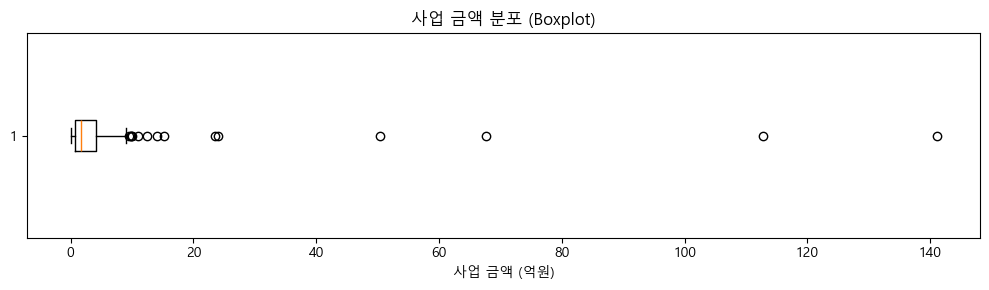

In [4]:
# 1-3. 이상치 탐지 (사업 금액)
amt = df['사업 금액'].dropna()

# 기본 통계
print("=== 사업 금액 기술통계 ===")
print(amt.describe().apply(lambda x: f"{x:,.0f}"))

# IQR 기반 이상치
Q1, Q3 = amt.quantile(0.25), amt.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['사업 금액'] < lower) | (df['사업 금액'] > upper)]
print(f"\nIQR 이상치 범위: {lower:,.0f} ~ {upper:,.0f}")
print(f"이상치 수: {len(outliers)}건")

# 금액 0원 건
zero_amt = df[df['사업 금액'] == 0]
print(f"\n금액 0원: {len(zero_amt)}건")
if len(zero_amt) > 0:
    print(zero_amt[['사업명', '발주 기관']].to_string())

# 이상치 목록
print(f"\n=== 이상치 목록 (상위) ===")
print(outliers[['사업명', '사업 금액', '발주 기관']].sort_values('사업 금액', ascending=False).to_string())

# boxplot
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(amt / 1e8, vert=False)
ax.set_xlabel('사업 금액 (억원)')
ax.set_title('사업 금액 분포 (Boxplot)')
plt.tight_layout()
plt.show()

## 1-4. 날짜 포맷 통일

공개 일자, 입찰 참여 시작일, 입찰 참여 마감일을 datetime으로 변환한다.  
- 파싱에 실패하는 행이 있는지 확인하여 날짜 형식 불일치 건을 식별한다.  
- 변환 후 연도/월 컬럼을 추가하여 이후 시계열 분석에 활용한다.  
- **기대 결과**: datetime 변환 성공/실패 건수, 날짜 범위 요약

In [5]:
# 1-4. 날짜 포맷 통일
date_cols = ['공개 일자', '입찰 참여 시작일', '입찰 참여 마감일']

for col in date_cols:
    df[col + '_dt'] = pd.to_datetime(df[col], errors='coerce')
    success = df[col + '_dt'].notna().sum()
    fail = df[col].notna().sum() - success
    total_null = df[col].isna().sum()
    print(f"[{col}] 변환 성공: {success}, 실패: {fail}, 원본 결측: {total_null}")

# 연도/월 컬럼 추가
df['공개_연도'] = df['공개 일자_dt'].dt.year
df['공개_월'] = df['공개 일자_dt'].dt.month
df['공개_연월'] = df['공개 일자_dt'].dt.to_period('M')

# 날짜 범위 요약
print(f"\n=== 날짜 범위 ===")
for col in date_cols:
    dt_col = col + '_dt'
    valid = df[dt_col].dropna()
    if len(valid) > 0:
        print(f"  {col}: {valid.min().strftime('%Y-%m-%d')} ~ {valid.max().strftime('%Y-%m-%d')}")
    else:
        print(f"  {col}: 유효한 날짜 없음")

[공개 일자] 변환 성공: 100, 실패: 0, 원본 결측: 0
[입찰 참여 시작일] 변환 성공: 74, 실패: 0, 원본 결측: 26
[입찰 참여 마감일] 변환 성공: 92, 실패: 0, 원본 결측: 8

=== 날짜 범위 ===
  공개 일자: 2021-10-08 ~ 2025-02-11
  입찰 참여 시작일: 2024-02-21 ~ 2025-02-11
  입찰 참여 마감일: 2024-02-26 ~ 2025-03-10


---
# 2단계: 기술 통계 & 분포 분석

## 2-1. 사업 금액 분포

사업 금액의 전체 분포를 히스토그램으로 시각화한다.  
- 로그 스케일을 병행하여 극단적 편차가 있는 분포도 직관적으로 파악한다.  
- 금액 구간별 사업 건수를 확인하여 소규모/중규모/대규모 비율을 파악한다.  
- **기대 결과**: 원본 스케일 + 로그 스케일 히스토그램, 금액 구간별 건수 테이블

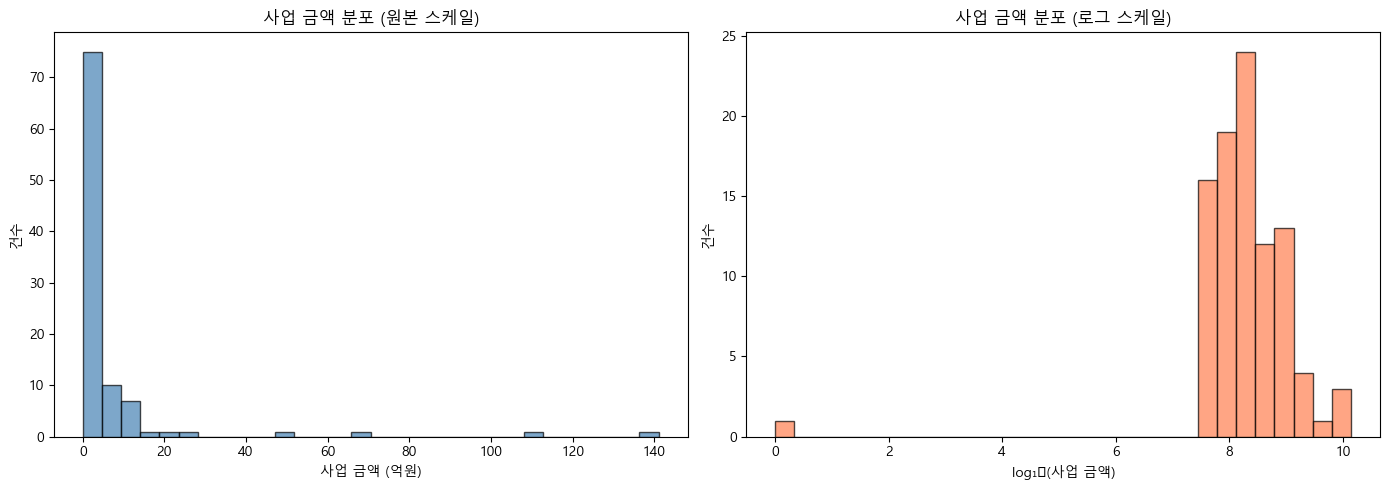

=== 금액 구간별 건수 ===
금액_구간
1억 미만     34
1~5억      43
5~10억     12
10~50억     6
50억 이상     4
Name: count, dtype: int64


In [6]:
# 2-1. 사업 금액 분포
amt_valid = df['사업 금액'].dropna()
amt_nonzero = amt_valid[amt_valid > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 스케일
axes[0].hist(amt_valid / 1e8, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('사업 금액 (억원)')
axes[0].set_ylabel('건수')
axes[0].set_title('사업 금액 분포 (원본 스케일)')

# 로그 스케일
axes[1].hist(np.log10(amt_nonzero), bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('log₁₀(사업 금액)')
axes[1].set_ylabel('건수')
axes[1].set_title('사업 금액 분포 (로그 스케일)')

plt.tight_layout()
plt.show()

# 금액 구간별 건수
bins = [0, 1e8, 5e8, 10e8, 50e8, float('inf')]
labels = ['1억 미만', '1~5억', '5~10억', '10~50억', '50억 이상']
df['금액_구간'] = pd.cut(df['사업 금액'], bins=bins, labels=labels, right=False)
print("=== 금액 구간별 건수 ===")
print(df['금액_구간'].value_counts().sort_index())

## 2-2. 발주 기관 분포

발주 기관별 공고 건수를 상위 15개 기관 기준으로 시각화한다.  
- 특정 기관에 공고가 집중되어 있는지 확인하여 시장 집중도를 파악한다.  
- RAG 시스템에서 기관명 기반 필터링이 유의미한지 판단하는 근거가 된다.  
- **기대 결과**: 상위 15개 발주 기관 수평 bar chart

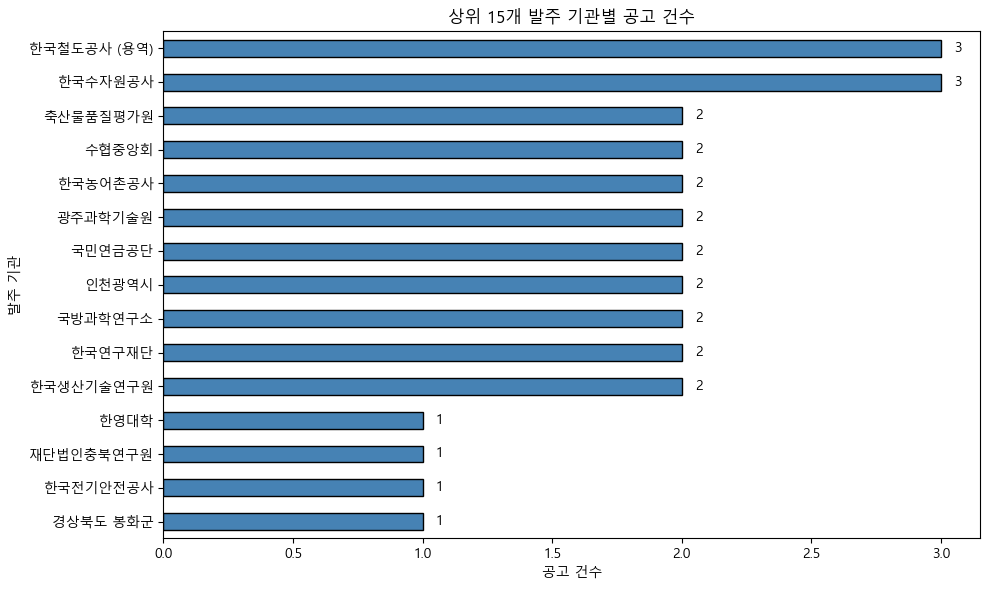


총 발주 기관 수: 87개
1건만 발주한 기관: 76개


In [7]:
# 2-2. 발주 기관 분포
top_orgs = df['발주 기관'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_orgs.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('공고 건수')
ax.set_ylabel('발주 기관')
ax.set_title('상위 15개 발주 기관별 공고 건수')

for i, v in enumerate(top_orgs.sort_values()):
    ax.text(v + 0.05, i, str(v), va='center')

plt.tight_layout()
plt.show()

print(f"\n총 발주 기관 수: {df['발주 기관'].nunique()}개")
print(f"1건만 발주한 기관: {(df['발주 기관'].value_counts() == 1).sum()}개")

## 2-3. 시계열 트렌드 (월별 공고 건수 추이)

공고 공개 일자를 기준으로 월별 공고 건수 추이를 시각화한다.  
- 특정 시기(분기말, 연말 등)에 공고가 집중되는 패턴이 있는지 확인한다.  
- 데이터의 시간적 편향을 파악하여 RAG 시스템의 시간 범위 필터링 설계에 참고한다.  
- **기대 결과**: 월별 공고 건수 라인차트 + 연도별 색상 구분

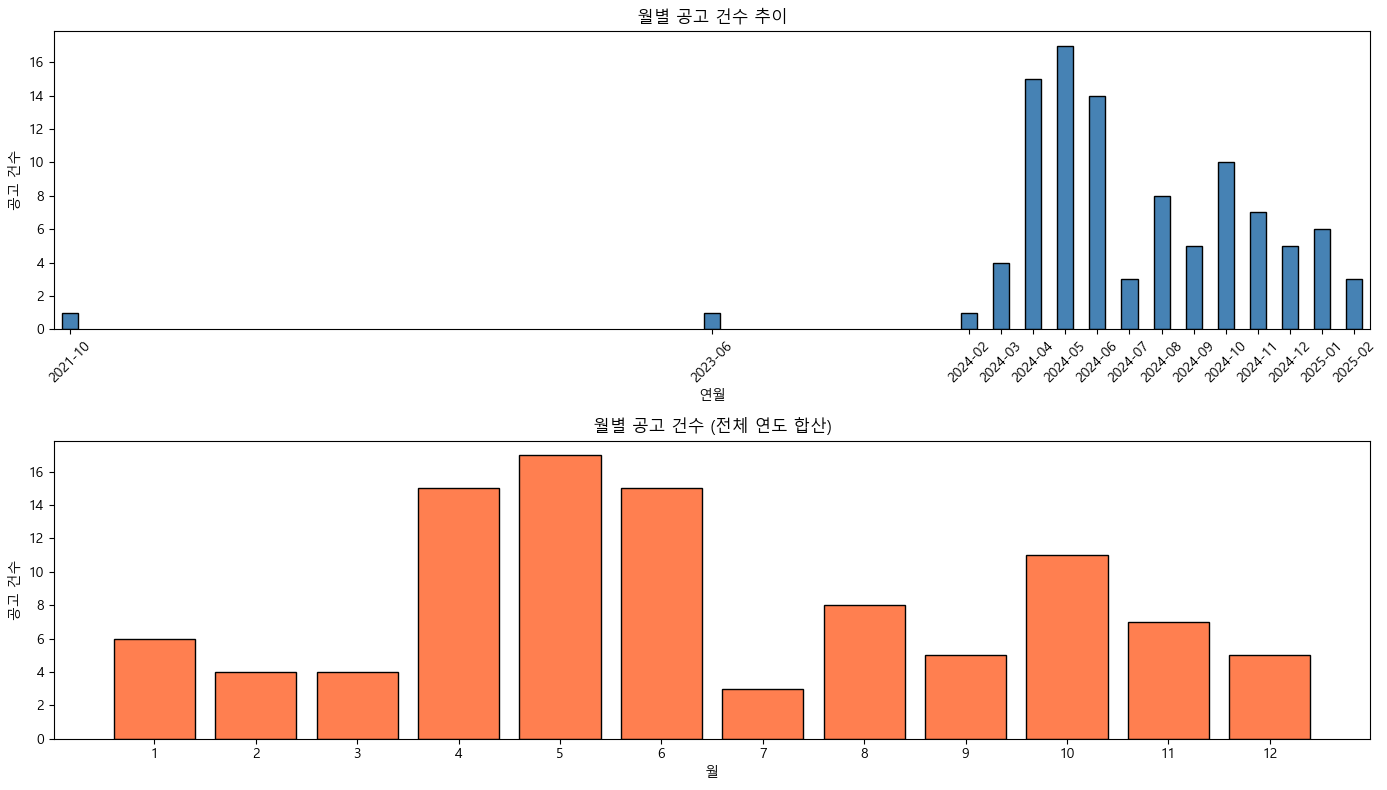

In [8]:
# 2-3. 시계열 트렌드
monthly = df.groupby('공개_연월').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 월별 추이
monthly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('연월')
axes[0].set_ylabel('공고 건수')
axes[0].set_title('월별 공고 건수 추이')
axes[0].tick_params(axis='x', rotation=45)

# 월별(1~12월) 집계
month_agg = df.groupby('공개_월').size()
axes[1].bar(month_agg.index, month_agg.values, color='coral', edgecolor='black')
axes[1].set_xlabel('월')
axes[1].set_ylabel('공고 건수')
axes[1].set_title('월별 공고 건수 (전체 연도 합산)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 2-4. 입찰 기간 분석

입찰 참여 마감일 - 입찰 참여 시작일로 입찰 준비 기간을 계산한다.  
- 평균 입찰 기간을 파악하고, 극단적으로 짧은 건(긴급 공고)을 식별한다.  
- 입찰 기간이 0일이거나 음수인 이상 데이터가 있는지도 함께 점검한다.  
- **기대 결과**: 입찰 기간 히스토그램 및 기술통계

=== 입찰 기간 기술통계 (일) ===
count    74.000000
mean      9.500000
std       9.104041
min       0.000000
25%       4.000000
50%       7.000000
75%      12.000000
max      45.000000
Name: 입찰_기간, dtype: float64

입찰 기간 0일 이하: 6건


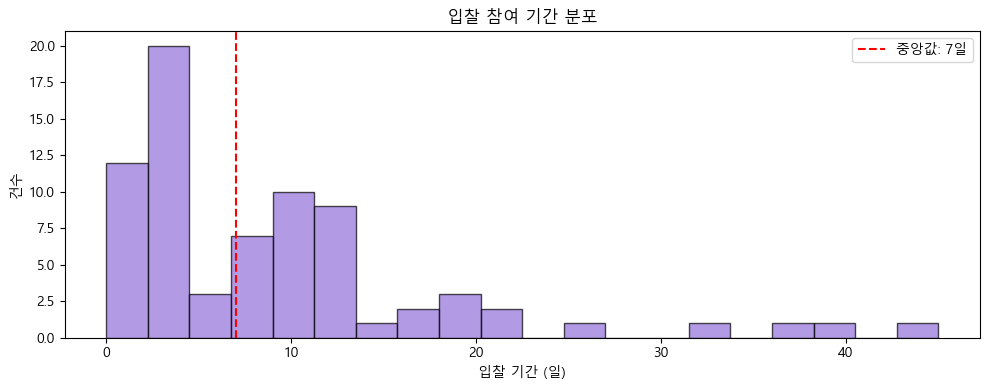

In [9]:
# 2-4. 입찰 기간 분석
df['입찰_기간'] = (df['입찰 참여 마감일_dt'] - df['입찰 참여 시작일_dt']).dt.days

bid_period = df['입찰_기간'].dropna()
print("=== 입찰 기간 기술통계 (일) ===")
print(bid_period.describe())

# 이상 데이터 확인
abnormal = df[df['입찰_기간'] <= 0]
print(f"\n입찰 기간 0일 이하: {len(abnormal)}건")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bid_period, bins=20, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(bid_period.median(), color='red', linestyle='--', label=f'중앙값: {bid_period.median():.0f}일')
ax.set_xlabel('입찰 기간 (일)')
ax.set_ylabel('건수')
ax.set_title('입찰 참여 기간 분포')
ax.legend()
plt.tight_layout()
plt.show()

---
# 3단계: 텍스트 분석 (RAG 핵심)

RAG 시스템의 성능은 원문 텍스트의 품질과 구조에 직접적으로 의존한다.  
이 단계에서는 청킹 전략, 전처리 범위, 임베딩 품질에 영향을 미치는 텍스트 특성을 집중 분석한다.

## 3-1. 텍스트 길이 분포

텍스트(원문) 컬럼의 길이 분포를 분석한다.  
- 문서 길이 편차가 크면 고정 길이 청킹 시 짧은 문서는 의미 없는 패딩이, 긴 문서는 정보 손실이 발생할 수 있다.  
- 길이 분포에 따라 고정 길이(fixed-size) vs 의미 단위(semantic) 청킹 전략을 결정한다.  
- **기대 결과**: 텍스트 길이 히스토그램, 기술통계, 길이 구간별 건수

=== 텍스트(원문) 길이 기술통계 ===
count       100
mean      3,844
std       3,693
min          89
25%       1,198
50%       2,583
75%       5,842
max      18,335
Name: 텍스트_길이, dtype: str

=== 사업 요약 길이 기술통계 ===
count    100
mean     269
std       73
min      142
25%      220
50%      250
75%      297
max      524
Name: 요약_길이, dtype: str


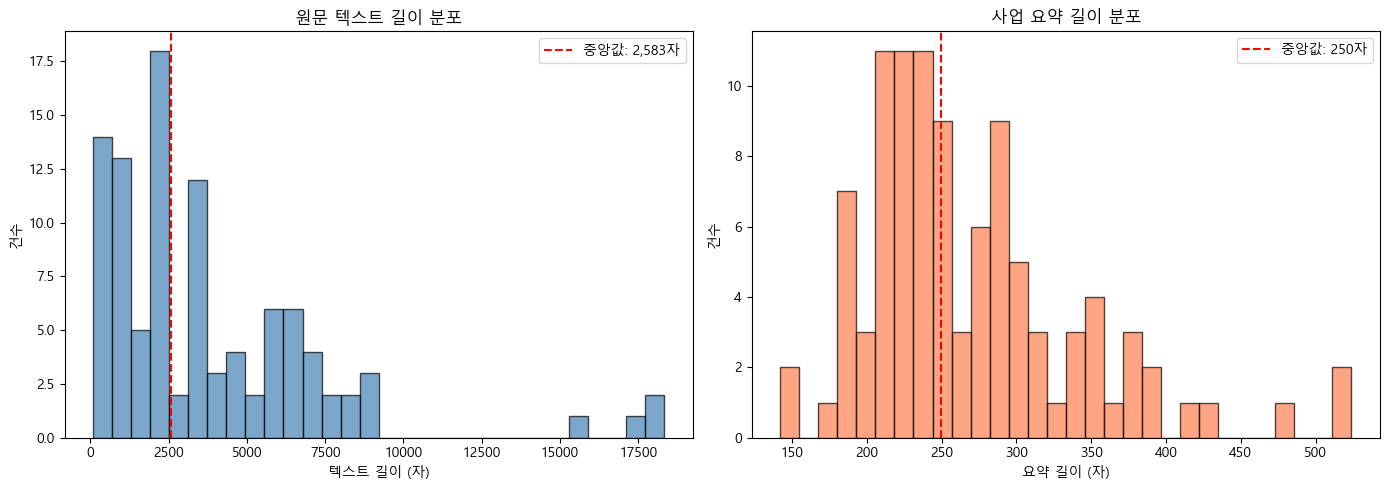


=== 텍스트 길이 구간별 건수 ===
텍스트_길이_구간
500자 미만     7
500~1K     14
1K~3K      31
3K~5K      19
5K~10K     25
10K 이상      4
Name: count, dtype: int64


In [10]:
# 3-1. 텍스트 길이 분포
df['텍스트_길이'] = df['텍스트'].str.len()
df['요약_길이'] = df['사업 요약'].str.len()

print("=== 텍스트(원문) 길이 기술통계 ===")
print(df['텍스트_길이'].describe().apply(lambda x: f"{x:,.0f}"))

print(f"\n=== 사업 요약 길이 기술통계 ===")
print(df['요약_길이'].describe().apply(lambda x: f"{x:,.0f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 텍스트 원문 길이
axes[0].hist(df['텍스트_길이'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['텍스트_길이'].median(), color='red', linestyle='--', label=f"중앙값: {df['텍스트_길이'].median():,.0f}자")
axes[0].set_xlabel('텍스트 길이 (자)')
axes[0].set_ylabel('건수')
axes[0].set_title('원문 텍스트 길이 분포')
axes[0].legend()

# 사업 요약 길이
axes[1].hist(df['요약_길이'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(df['요약_길이'].median(), color='red', linestyle='--', label=f"중앙값: {df['요약_길이'].median():,.0f}자")
axes[1].set_xlabel('요약 길이 (자)')
axes[1].set_ylabel('건수')
axes[1].set_title('사업 요약 길이 분포')
axes[1].legend()

plt.tight_layout()
plt.show()

# 길이 구간별 건수
text_bins = [0, 500, 1000, 3000, 5000, 10000, float('inf')]
text_labels = ['500자 미만', '500~1K', '1K~3K', '3K~5K', '5K~10K', '10K 이상']
df['텍스트_길이_구간'] = pd.cut(df['텍스트_길이'], bins=text_bins, labels=text_labels, right=False)
print("\n=== 텍스트 길이 구간별 건수 ===")
print(df['텍스트_길이_구간'].value_counts().sort_index())

## 3-2. 텍스트 품질 점검

hwp/pdf → 텍스트 변환 과정에서 발생하는 노이즈를 정량적으로 측정한다.  
- **연속 공백/줄바꿈**: 표나 레이아웃이 깨지면서 생기는 불필요한 공백 → 임베딩 시 의미 희석  
- **특수문자 비율**: 깨진 문자, 제어문자 등이 많으면 토크나이저 성능 저하  
- **짧은 줄 비율**: 머리글/꼬리글/페이지번호 등 반복 패턴 식별  
- **기대 결과**: 문서별 노이즈 지표 테이블, 노이즈가 심한 문서 샘플 확인

=== 텍스트 품질 지표 통계 ===
        공백비율  특수문자비율  연속공백수  짧은줄비율
count  100.0   100.0  100.0  100.0
mean    37.7     0.4   57.4   19.1
std      7.8     0.4   38.9   10.9
min     17.1     0.0    1.0    0.0
25%     32.6     0.1   30.8   11.7
50%     37.1     0.3   53.0   17.6
75%     41.9     0.5   81.2   25.6
max     58.2     2.4  162.0   54.2

=== 공백비율 상위 5개 문서 ===
                                                    사업명  공백비율  특수문자비율  연속공백수  텍스트_길이
53                                       통합정보시스템 고도화 용역  58.2     0.0   48.0     706
56                             서민금융진흥원 서민금융 채팅 상담시스템 구축  57.7     0.4   44.0     759
52  아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교육시스템 고도화 2차사업  53.6     0.0   49.0     806
82                       2024년 항해용 간행물 품질관리 업무보조 시스템 구축  53.5     0.0   39.0     736
74                               광주정책연구아카이브(GPA) 시스템 개발  51.6     0.3   33.0     734

=== 특수문자비율 상위 5개 문서 ===
                                   사업명  특수문자비율  공백비율  텍스트_길이
59  기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고도화 사업     2.

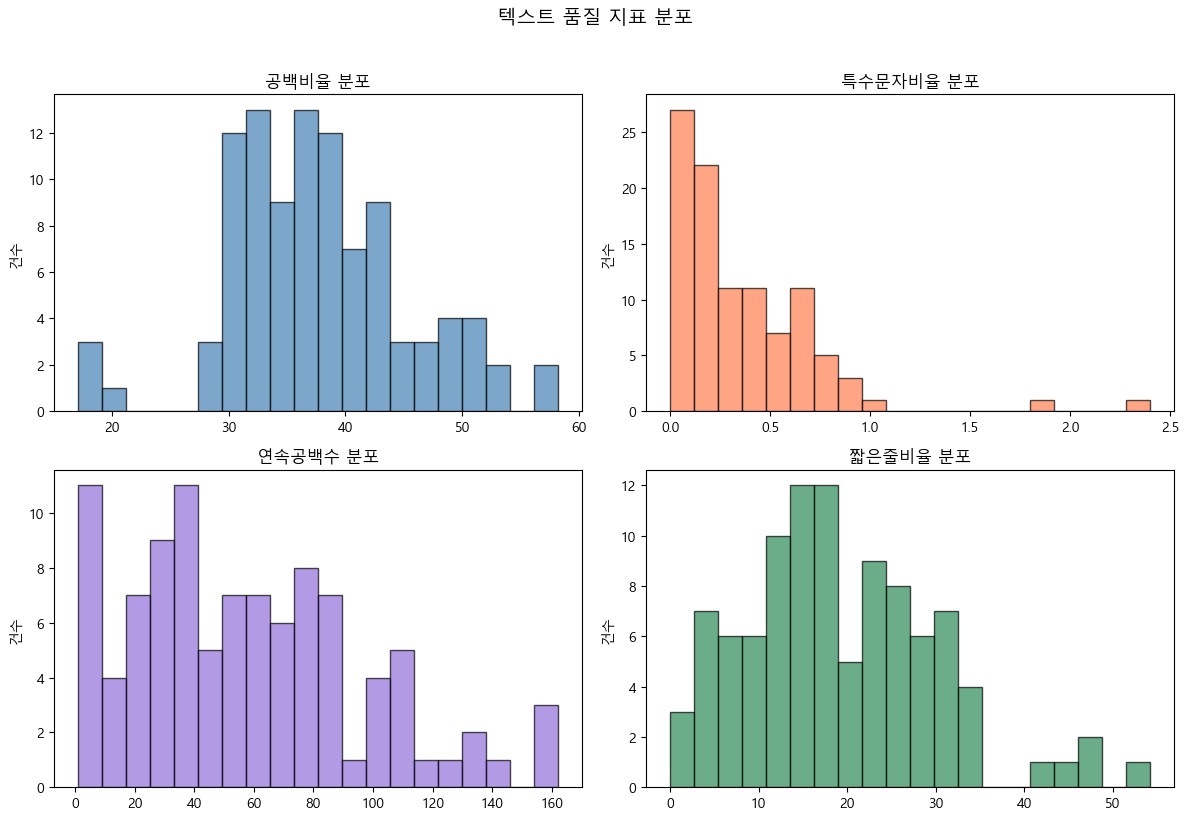

In [11]:
# 3-2. 텍스트 품질 점검

def text_quality_metrics(text):
    """텍스트 품질 지표를 계산한다."""
    total_len = len(text)
    if total_len == 0:
        return {'공백비율': 0, '특수문자비율': 0, '연속공백수': 0, '짧은줄비율': 0}

    # 공백 비율 (스페이스 + 탭 + 줄바꿈)
    whitespace_ratio = len(re.findall(r'\s', text)) / total_len * 100

    # 특수문자 비율 (한글, 영문, 숫자, 기본 구두점 제외)
    special = re.findall(r'[^\w\s가-힣a-zA-Z0-9.,·\-()（）「」\[\]/:;!?%]', text)
    special_ratio = len(special) / total_len * 100

    # 연속 공백 (3개 이상) 횟수
    consecutive_spaces = len(re.findall(r' {3,}', text))

    # 짧은 줄 비율 (5자 이하인 줄의 비율)
    lines = text.split('\n')
    short_lines = sum(1 for line in lines if 0 < len(line.strip()) <= 5)
    short_line_ratio = short_lines / max(len(lines), 1) * 100

    return {
        '공백비율': round(whitespace_ratio, 1),
        '특수문자비율': round(special_ratio, 1),
        '연속공백수': consecutive_spaces,
        '짧은줄비율': round(short_line_ratio, 1)
    }

quality = df['텍스트'].apply(text_quality_metrics).apply(pd.Series)
df = pd.concat([df, quality], axis=1)

print("=== 텍스트 품질 지표 통계 ===")
print(quality.describe().round(1))

# 노이즈가 심한 문서 상위 5개
print(f"\n=== 공백비율 상위 5개 문서 ===")
top_ws = df.nlargest(5, '공백비율')[['사업명', '공백비율', '특수문자비율', '연속공백수', '텍스트_길이']]
print(top_ws.to_string())

print(f"\n=== 특수문자비율 상위 5개 문서 ===")
top_sp = df.nlargest(5, '특수문자비율')[['사업명', '특수문자비율', '공백비율', '텍스트_길이']]
print(top_sp.to_string())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['공백비율', '특수문자비율', '연속공백수', '짧은줄비율']
colors = ['steelblue', 'coral', 'mediumpurple', 'seagreen']

for ax, metric, color in zip(axes.flat, metrics, colors):
    ax.hist(df[metric], bins=20, edgecolor='black', alpha=0.7, color=color)
    ax.set_title(f'{metric} 분포')
    ax.set_ylabel('건수')

plt.suptitle('텍스트 품질 지표 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3-3. 문서 구조 패턴 분석

원문 텍스트에서 섹션 헤더, 목차, 표 구분자 등 구조적 패턴을 탐지한다.  
- 섹션 헤더(Ⅰ, Ⅱ, 1., 2., 가., 나. 등)가 존재하면 **의미 단위 청킹**이 가능하다.  
- 목차 패턴이 있으면 문서 구조를 메타데이터로 활용하여 검색 정확도를 높일 수 있다.  
- 표 구분자(---|, 탭 등)는 표 데이터의 전처리 전략에 영향을 미친다.  
- **기대 결과**: 구조 패턴별 존재 비율, 샘플 문서의 구조 시각화

=== 문서 구조 패턴 존재 비율 ===
  로마숫자 헤더 (Ⅰ,Ⅱ,Ⅲ...): 85건 (85%)
  숫자 헤더 (1., 2., 3.): 95건 (95%)
  한글 헤더 (가., 나., 다.): 35건 (35%)
  괄호 번호 (1), (2), (3): 8건 (8%)
  목차 패턴 (-  숫자): 84건 (84%)
  표 구분자 (탭 문자): 82건 (82%)
  글머리 기호 (○, ●, ◎, ■): 1건 (1%)
  페이지 번호 패턴: 49건 (49%)


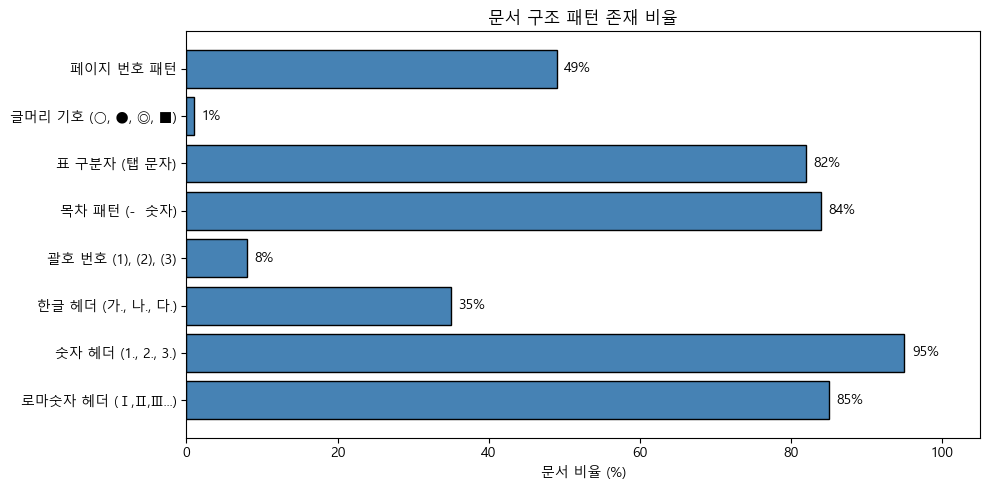

In [12]:
# 3-3. 문서 구조 패턴 분석

structure_patterns = {
    '로마숫자 헤더 (Ⅰ,Ⅱ,Ⅲ...)': r'[ⅠⅡⅢⅣⅤⅥⅦⅧⅨⅩ]',
    '숫자 헤더 (1., 2., 3.)': r'^\s*\d+\.\s',
    '한글 헤더 (가., 나., 다.)': r'^\s*[가나다라마바사아자차카타파하]\.',
    '괄호 번호 (1), (2), (3)': r'\(\d+\)',
    '목차 패턴 (-  숫자)': r'-\s+\d+',
    '표 구분자 (탭 문자)': r'\t',
    '글머리 기호 (○, ●, ◎, ■)': r'[○●◎■□◇▶▷►]',
    '페이지 번호 패턴': r'^\s*-?\s*\d{1,3}\s*-?\s*$',
}

print("=== 문서 구조 패턴 존재 비율 ===")
pattern_results = {}
for name, pattern in structure_patterns.items():
    has_pattern = df['텍스트'].apply(lambda x: bool(re.search(pattern, x, re.MULTILINE)))
    count = has_pattern.sum()
    ratio = count / len(df) * 100
    pattern_results[name] = ratio
    print(f"  {name}: {count}건 ({ratio:.0f}%)")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
names = list(pattern_results.keys())
values = list(pattern_results.values())
bars = ax.barh(names, values, color='steelblue', edgecolor='black')
ax.set_xlabel('문서 비율 (%)')
ax.set_title('문서 구조 패턴 존재 비율')
ax.set_xlim(0, 105)

for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}%', va='center')

plt.tight_layout()
plt.show()

## 3-4. 핵심 키워드/용어 빈도

사업명과 원문 텍스트에서 자주 등장하는 키워드를 추출한다.  
- 형태소 분석 없이 정규식 기반으로 2~6자 한글 명사 후보를 추출하여 빈도를 집계한다.  
- 사용자가 RAG 시스템에 질의할 때 사용할 도메인 용어를 사전에 파악한다.  
- 고빈도 용어는 임베딩 모델의 도메인 적합성 평가 및 검색 쿼리 튜닝에 활용된다.  
- **기대 결과**: 사업명 기반 상위 30개 키워드 bar chart, 원문 텍스트 기반 상위 30개 키워드

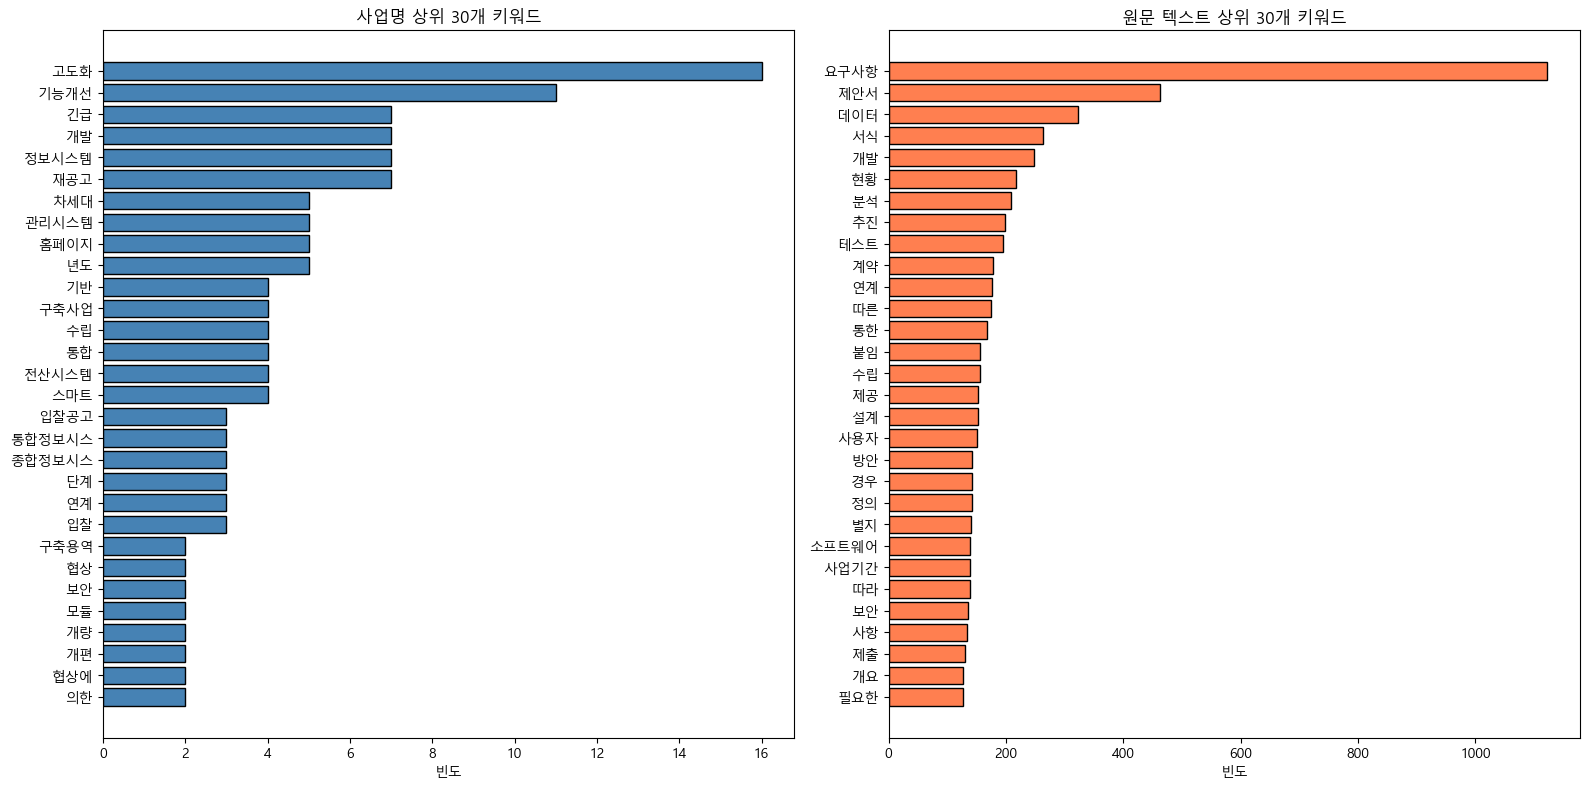

In [13]:
# 3-4. 핵심 키워드/용어 빈도

# 불용어 정의 (분석에 의미 없는 일반 단어)
stopwords = {'사업', '용역', '구축', '운영', '시스템', '정보', '기관', '대학', '위한',
             '관련', '관리', '기능', '개선', '서비스', '제안', '요청', '업무', '기술',
             '평가', '방법', '내용', '범위', '일정', '기간', '지원', '수행', '대한',
             '있는', '있다', '없는', '없다', '하는', '한다', '이상', '이하', '포함',
             '등을', '에서', '으로', '까지', '부터', '에는', '에게', '에의', '것을'}

def extract_keywords(text, min_len=2, max_len=6):
    """한글 키워드 후보 추출"""
    words = re.findall(r'[가-힣]{' + str(min_len) + ',' + str(max_len) + '}', text)
    return [w for w in words if w not in stopwords]

# 사업명에서 키워드 추출
name_keywords = Counter()
for name in df['사업명']:
    name_keywords.update(extract_keywords(str(name)))

# 원문 텍스트에서 키워드 추출
text_keywords = Counter()
for text in df['텍스트']:
    text_keywords.update(extract_keywords(str(text)))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 사업명 키워드
top_name = name_keywords.most_common(30)
words_n, counts_n = zip(*top_name)
axes[0].barh(list(reversed(words_n)), list(reversed(counts_n)), color='steelblue', edgecolor='black')
axes[0].set_xlabel('빈도')
axes[0].set_title('사업명 상위 30개 키워드')

# 텍스트 키워드
top_text = text_keywords.most_common(30)
words_t, counts_t = zip(*top_text)
axes[1].barh(list(reversed(words_t)), list(reversed(counts_t)), color='coral', edgecolor='black')
axes[1].set_xlabel('빈도')
axes[1].set_title('원문 텍스트 상위 30개 키워드')

plt.tight_layout()
plt.show()

## 3-5. 사업 요약 워드클라우드

사업 요약 텍스트를 기반으로 워드클라우드를 생성한다.  
- 전체 공고의 핵심 주제와 도메인을 시각적으로 한눈에 파악할 수 있다.  
- 자주 등장하는 키워드는 RAG 시스템의 사업 유형 카테고리 설계 기반이 된다.  
- **기대 결과**: 사업 요약 기반 워드클라우드 이미지  
- **참고**: `wordcloud` 패키지가 설치되어 있지 않으면 bar chart로 대체한다.

wordcloud 패키지 미설치 → bar chart로 대체


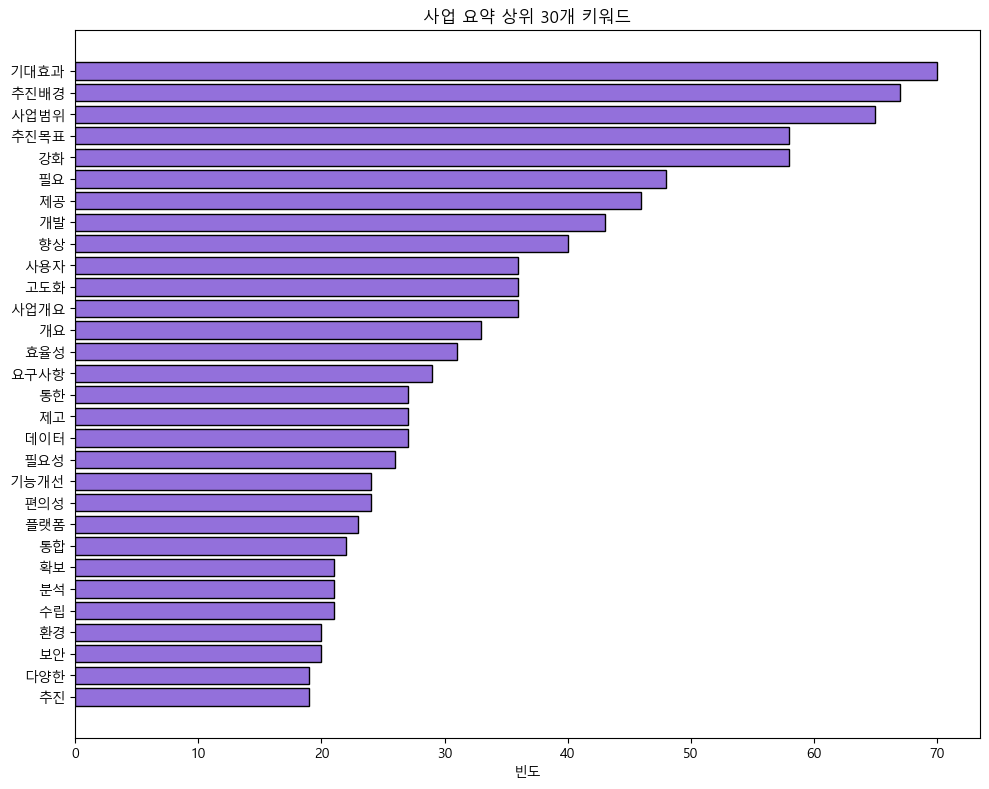

In [14]:
# 3-5. 사업 요약 워드클라우드

# 사업 요약에서 키워드 추출
summary_keywords = Counter()
for summary in df['사업 요약']:
    summary_keywords.update(extract_keywords(str(summary)))

try:
    from wordcloud import WordCloud

    font_path = 'C:/Windows/Fonts/malgun.ttf'
    wc = WordCloud(
        font_path=font_path,
        width=1200, height=600,
        background_color='white',
        max_words=100,
        colormap='viridis'
    )
    wc.generate_from_frequencies(summary_keywords)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('사업 요약 워드클라우드', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("wordcloud 패키지 미설치 → bar chart로 대체")
    top_summary = summary_keywords.most_common(30)
    words_s, counts_s = zip(*top_summary)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(list(reversed(words_s)), list(reversed(counts_s)), color='mediumpurple', edgecolor='black')
    ax.set_xlabel('빈도')
    ax.set_title('사업 요약 상위 30개 키워드')
    plt.tight_layout()
    plt.show()

## 3-6. 문서 간 유사도/중복 분석

TF-IDF 벡터화 후 코사인 유사도 매트릭스를 계산하여 문서 간 유사도를 분석한다.  
- 유사도가 높은 문서 쌍이 많으면 RAG 검색 시 동일한 내용이 반복 반환될 수 있다.  
- 유사도 분포를 통해 중복 제거 임계값을 설정하거나 가중치 조정 전략을 수립한다.  
- **기대 결과**: 유사도 히트맵, 유사도 분포 히스토그램, 가장 유사한 문서 쌍 Top 10

=== 문서 간 유사도 통계 ===
  평균: 0.0811
  중앙값: 0.0685
  최대값: 0.6384
  유사도 > 0.5: 1쌍
  유사도 > 0.7: 0쌍
  유사도 > 0.9: 0쌍


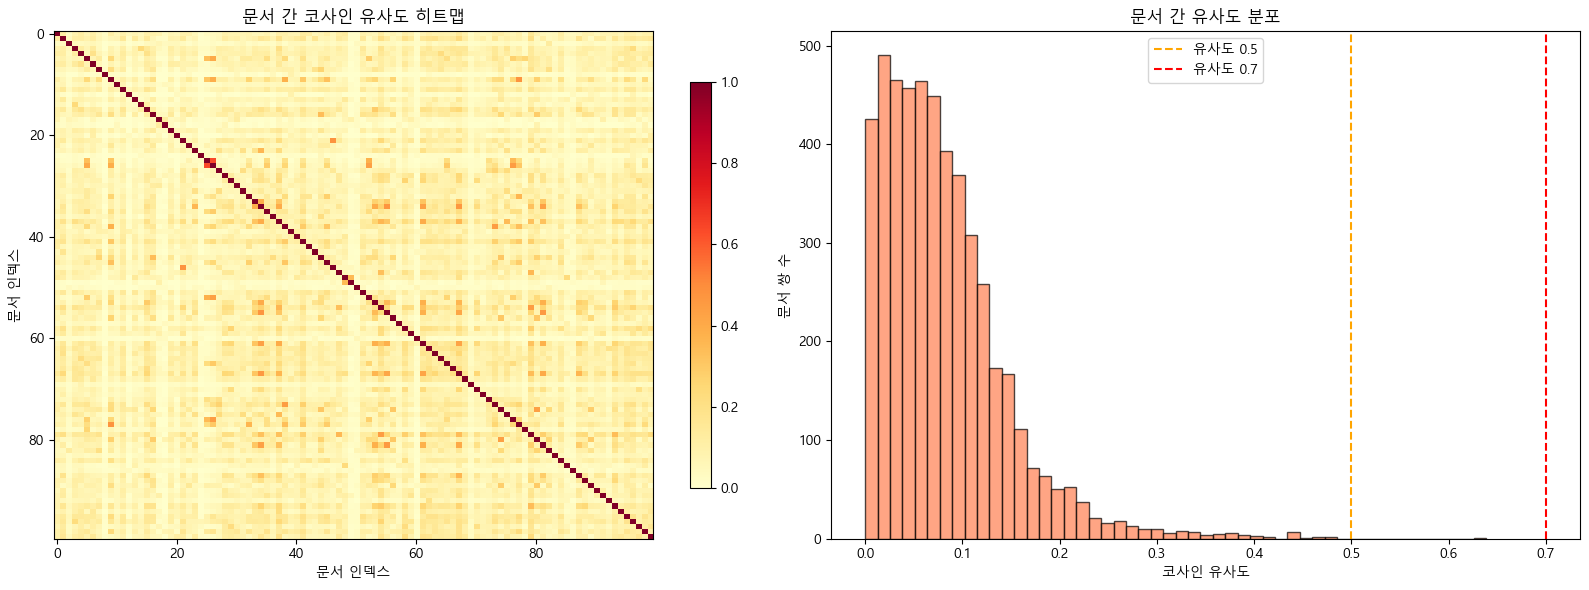


=== 가장 유사한 문서 쌍 Top 10 ===
  유사도 0.6384
    문서A: 아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아)사업 PMC 용역
    문서B: [긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 및 지역

  유사도 0.4802
    문서A: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업
    문서B: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)

  유사도 0.4750
    문서A: 대용량 자료전송시스템 고도화
    문서B: 꿀 품질평가 전산시스템 기능개선 사업

  유사도 0.4690
    문서A: 모바일오피스 시스템 고도화 용역(총체 및 1차)
    문서B: 2세대 전자조달시스템  기반구축사업

  유사도 0.4628
    문서A: 모바일오피스 시스템 고도화 용역(총체 및 1차)
    문서B: 국가교육과정정보센터(NCIC) 시스템 운영 및 개선

  유사도 0.4596
    문서A: 2세대 전자조달시스템  기반구축사업
    문서B: 한국원자력연구원 선량평가시스템 고도화

  유사도 0.4460
    문서A: [긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 및 지역
    문서B: [혁신-국고] 남서울대학교 스마트 정보시스템 활성화(학사행정 암호화) 개발 용역 입찰

  유사도 0.4450
    문서A: 학사시스템 기능개선 사업
    문서B: 실시간통합연구비관리시스템(RCMS)  연계 모듈 변경 사업

  유사도 0.4430
    문서A: 한국어촌어항공단 경영관리시스템(ERP·GW) 기능 고도화 용역
    문서B: 인천공항운영서비스㈜ 차세대 ERP시스템 구축 사업(재공고)

  유사도 0.4364
    문서A: 광주정책연구아카이브(GPA) 시스템 개발
    문서B: RFID기반 국가자격 시험 결과물 스마트 관리시스템 도입 사업



In [15]:
# 3-6. 문서 간 유사도/중복 분석
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF 벡터화
tfidf = TfidfVectorizer(max_features=5000, token_pattern=r'[가-힣]{2,}')
tfidf_matrix = tfidf.fit_transform(df['텍스트'])

# 코사인 유사도
cos_sim = cosine_similarity(tfidf_matrix)

# 대각선 제외한 상삼각 행렬에서 유사도 추출
upper_tri = np.triu_indices_from(cos_sim, k=1)
sim_values = cos_sim[upper_tri]

print("=== 문서 간 유사도 통계 ===")
print(f"  평균: {sim_values.mean():.4f}")
print(f"  중앙값: {np.median(sim_values):.4f}")
print(f"  최대값: {sim_values.max():.4f}")
print(f"  유사도 > 0.5: {(sim_values > 0.5).sum()}쌍")
print(f"  유사도 > 0.7: {(sim_values > 0.7).sum()}쌍")
print(f"  유사도 > 0.9: {(sim_values > 0.9).sum()}쌍")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 유사도 히트맵
im = axes[0].imshow(cos_sim, cmap='YlOrRd', aspect='auto')
axes[0].set_title('문서 간 코사인 유사도 히트맵')
axes[0].set_xlabel('문서 인덱스')
axes[0].set_ylabel('문서 인덱스')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# 유사도 분포
axes[1].hist(sim_values, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0.5, color='orange', linestyle='--', label='유사도 0.5')
axes[1].axvline(0.7, color='red', linestyle='--', label='유사도 0.7')
axes[1].set_xlabel('코사인 유사도')
axes[1].set_ylabel('문서 쌍 수')
axes[1].set_title('문서 간 유사도 분포')
axes[1].legend()

plt.tight_layout()
plt.show()

# 가장 유사한 문서 쌍 Top 10
top_pairs = np.argsort(sim_values)[::-1][:10]
print(f"\n=== 가장 유사한 문서 쌍 Top 10 ===")
for idx in top_pairs:
    i, j = upper_tri[0][idx], upper_tri[1][idx]
    print(f"  유사도 {cos_sim[i][j]:.4f}")
    print(f"    문서A: {df.iloc[i]['사업명'][:50]}")
    print(f"    문서B: {df.iloc[j]['사업명'][:50]}")
    print()

## 3-7. 텍스트 길이 vs 사업 금액 상관관계

제안요청서(원문 텍스트)의 길이와 사업 금액 간의 상관관계를 분석한다.  
- 양의 상관이 있다면 사업 규모가 클수록 제안요청서가 상세하다는 의미 → 청킹 시 문서 메타데이터(금액)를 길이 예측에 활용 가능  
- 상관이 없다면 텍스트 길이는 독립적인 변수로, 별도의 청킹 전략이 필요  
- **기대 결과**: 산점도 + 상관계수, 금액 구간별 평균 텍스트 길이

=== 상관계수 ===
  피어슨 상관계수 (원본): 0.0287
  피어슨 상관계수 (로그 금액): -0.0850


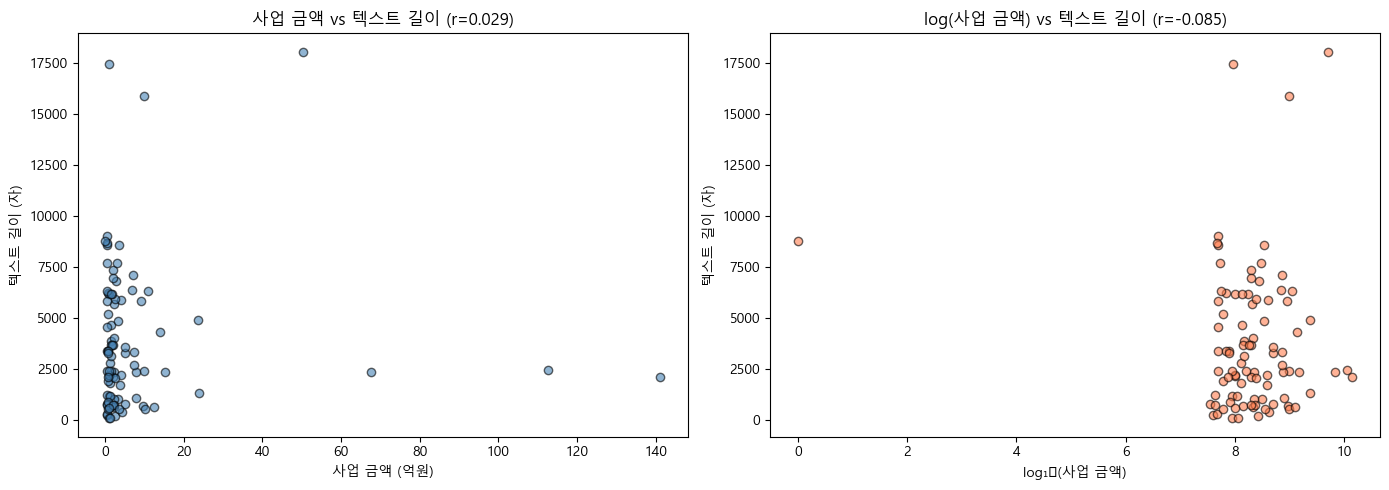


=== 금액 구간별 평균 텍스트 길이 ===
         평균 길이  중앙값 길이  건수
금액_구간                     
1억 미만   4313.0  3321.0  34
1~5억    3239.0  2407.0  43
5~10억   4298.0  2998.0  12
10~50억  3314.0  3344.0   6
50억 이상  6238.0  2400.0   4


In [16]:
# 3-7. 텍스트 길이 vs 사업 금액 상관관계
valid = df.dropna(subset=['사업 금액'])
valid = valid[valid['사업 금액'] > 0]

corr = valid['텍스트_길이'].corr(valid['사업 금액'])
log_corr = valid['텍스트_길이'].corr(np.log10(valid['사업 금액']))

print(f"=== 상관계수 ===")
print(f"  피어슨 상관계수 (원본): {corr:.4f}")
print(f"  피어슨 상관계수 (로그 금액): {log_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 스케일
axes[0].scatter(valid['사업 금액'] / 1e8, valid['텍스트_길이'], alpha=0.6, color='steelblue', edgecolor='black')
axes[0].set_xlabel('사업 금액 (억원)')
axes[0].set_ylabel('텍스트 길이 (자)')
axes[0].set_title(f'사업 금액 vs 텍스트 길이 (r={corr:.3f})')

# 로그 스케일
axes[1].scatter(np.log10(valid['사업 금액']), valid['텍스트_길이'], alpha=0.6, color='coral', edgecolor='black')
axes[1].set_xlabel('log₁₀(사업 금액)')
axes[1].set_ylabel('텍스트 길이 (자)')
axes[1].set_title(f'log(사업 금액) vs 텍스트 길이 (r={log_corr:.3f})')

plt.tight_layout()
plt.show()

# 금액 구간별 평균 텍스트 길이
print(f"\n=== 금액 구간별 평균 텍스트 길이 ===")
group_stats = df.groupby('금액_구간', observed=False)['텍스트_길이'].agg(['mean', 'median', 'count'])
group_stats.columns = ['평균 길이', '중앙값 길이', '건수']
print(group_stats.round(0))

---
# 4단계: 교차 분석

## 4-1. 기관 유형별 평균 사업 금액

발주 기관명에서 키워드를 추출하여 기관 유형(공공기관/대학/지자체/공사공단/재단 등)으로 분류한다.  
- 기관 유형별 평균 사업 금액 차이를 비교하여, 유형에 따른 사업 규모 특성을 파악한다.  
- RAG 시스템에서 기관 유형을 메타데이터 필터로 활용할지 판단하는 근거가 된다.  
- **기대 결과**: 기관 유형별 건수/평균금액 테이블, 비교 bar chart

=== 기관 유형별 통계 ===
         건수   평균금액 중앙값금액
기관_유형                   
기타 공공기관  26   7.1억  2.1억
공사/공단    20  11.3억  3.1억
지자체      12   3.9억  2.2억
대학       11  11.7억  1.0억
진흥/평가기관  11   1.0억  0.8억
재단        8   2.3억  1.7억
연구기관      7   2.4억  1.4억
협회/사단법인   5  11.7억  2.4억


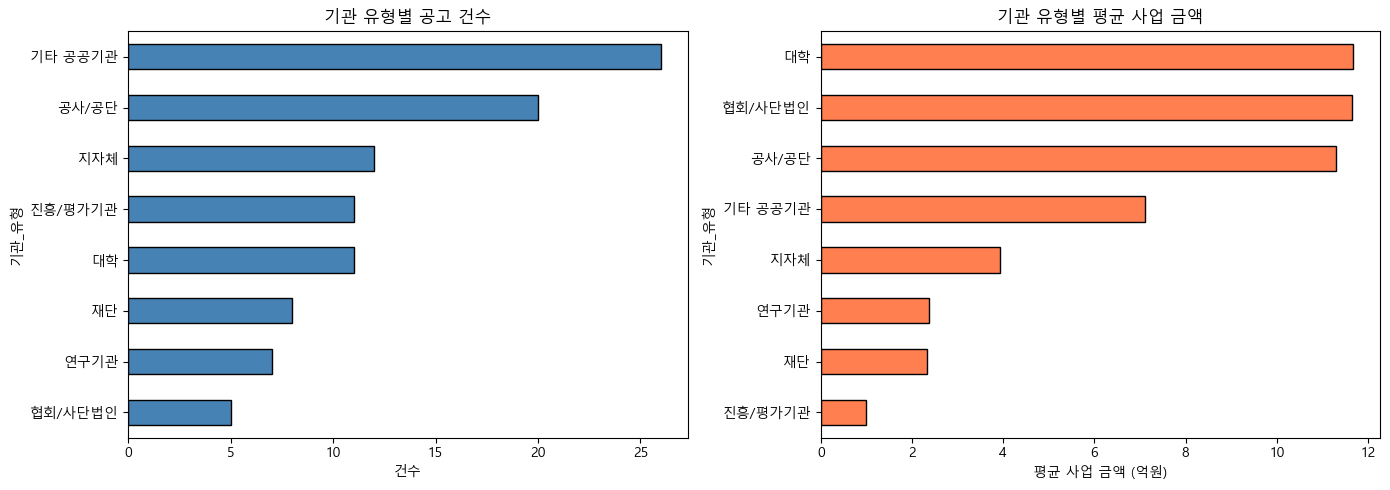

In [17]:
# 4-1. 기관 유형별 평균 사업 금액

def classify_org(name):
    """발주 기관명으로 기관 유형을 분류한다."""
    if any(kw in name for kw in ['대학', '대학교']):
        return '대학'
    elif any(kw in name for kw in ['시 ', '도 ', '군_', '구_', '특별시', '광역시', '특별자치']):
        return '지자체'
    elif any(kw in name for kw in ['공사', '공단']):
        return '공사/공단'
    elif any(kw in name for kw in ['재단', '재단법인']):
        return '재단'
    elif any(kw in name for kw in ['협회', '사단법인', '(사)']):
        return '협회/사단법인'
    elif any(kw in name for kw in ['연구원', '연구소', '연구재단']):
        return '연구기관'
    elif any(kw in name for kw in ['진흥원', '진흥회', '평가원', '정보원']):
        return '진흥/평가기관'
    else:
        return '기타 공공기관'

df['기관_유형'] = df['발주 기관'].apply(classify_org)

# 기관 유형별 통계
org_stats = df.groupby('기관_유형').agg(
    건수=('사업명', 'count'),
    평균금액=('사업 금액', 'mean'),
    중앙값금액=('사업 금액', 'median')
).sort_values('건수', ascending=False)
org_stats['평균금액'] = org_stats['평균금액'].apply(lambda x: f"{x / 1e8:.1f}억")
org_stats['중앙값금액'] = org_stats['중앙값금액'].apply(lambda x: f"{x / 1e8:.1f}억")

print("=== 기관 유형별 통계 ===")
print(org_stats)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 건수
type_counts = df['기관_유형'].value_counts()
type_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('건수')
axes[0].set_title('기관 유형별 공고 건수')

# 평균 금액
type_mean_amt = df.groupby('기관_유형')['사업 금액'].mean().sort_values() / 1e8
type_mean_amt.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('평균 사업 금액 (억원)')
axes[1].set_title('기관 유형별 평균 사업 금액')

plt.tight_layout()
plt.show()

## 4-2. 재공고(공고 차수 > 0) 특성 분석

공고 차수가 1 이상인 재공고 건의 특성을 분석한다.  
- 재공고(유찰 후 재입찰)되는 사업의 금액, 기관 유형, 입찰 기간 등을 비교하여 유찰 패턴을 파악한다.  
- RAG 시스템에서 재공고 여부를 메타데이터로 활용할 수 있는지 판단한다.  
- **기대 결과**: 초공고 vs 재공고 비교 테이블, 금액 분포 비교 boxplot

=== 초공고 vs 재공고 비교 ===
        건수  평균금액 중앙값금액  평균텍스트길이
재공고_여부                         
재공고      6  2.7억  1.4억   4775.0
초공고     76  3.9억  1.7억   3886.0

=== 재공고 건 목록 (6건) ===
                                                    사업명  공고 차수        사업 금액        발주 기관    기관_유형
19     관산근린공원 다목적구장 홈페이지 및 회원 통합운영 관리 시스템 구축[협상에 의한 계약]    1.0   90000000.0     고양도시관리공사    공사/공단
25         아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아)사업 PMC 용역    1.0  977240000.0      한국농어촌공사    공사/공단
37               정읍체육트레이닝센터 통합운영관리시스템 구축 용역(협상에의한계약,긴급)    1.0  200000000.0  전북특별자치도 정읍시      지자체
52  아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교육시스템 고도화 2차사업    1.0   35750000.0         대검찰청  기타 공공기관
61       평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 및 홍수감시 시스템 연동 개발    2.0  341000000.0     케빈랩 주식회사  기타 공공기관
83                                실손보험 청구 전산화 시스템 구축 사업    2.0          1.0   사단법인 보험개발원  협회/사단법인


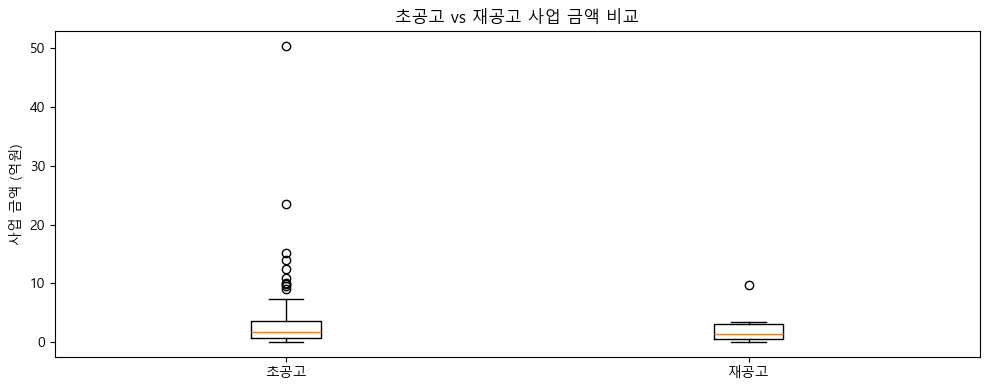

In [18]:
# 4-2. 재공고 특성 분석
df_valid_round = df.dropna(subset=['공고 차수'])
df_valid_round['재공고_여부'] = df_valid_round['공고 차수'].apply(lambda x: '재공고' if x > 0 else '초공고')

print("=== 초공고 vs 재공고 비교 ===")
comparison = df_valid_round.groupby('재공고_여부').agg(
    건수=('사업명', 'count'),
    평균금액=('사업 금액', lambda x: f"{x.mean() / 1e8:.1f}억"),
    중앙값금액=('사업 금액', lambda x: f"{x.median() / 1e8:.1f}억"),
    평균텍스트길이=('텍스트_길이', 'mean')
).round(0)
print(comparison)

# 재공고 건 상세
reannounce = df_valid_round[df_valid_round['공고 차수'] > 0]
print(f"\n=== 재공고 건 목록 ({len(reannounce)}건) ===")
if len(reannounce) > 0:
    print(reannounce[['사업명', '공고 차수', '사업 금액', '발주 기관', '기관_유형']].to_string())

# 금액 분포 비교
if len(reannounce) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    data_to_plot = [
        df_valid_round[df_valid_round['재공고_여부'] == '초공고']['사업 금액'].dropna() / 1e8,
        df_valid_round[df_valid_round['재공고_여부'] == '재공고']['사업 금액'].dropna() / 1e8
    ]
    ax.boxplot(data_to_plot, labels=['초공고', '재공고'])
    ax.set_ylabel('사업 금액 (억원)')
    ax.set_title('초공고 vs 재공고 사업 금액 비교')
    plt.tight_layout()
    plt.show()

## 4-3. 금액 구간별 사업 특성

사업 금액을 소규모(<1억) / 중규모(1~5억) / 대규모(>5억)로 나누어 각 구간의 특성을 비교한다.  
- 기관 유형 분포, 텍스트 길이, 입찰 기간 등을 구간별로 비교하여 사업 규모에 따른 패턴을 파악한다.  
- RAG 시스템에서 금액 기반 필터링이나 사업 규모별 맞춤 검색 전략 설계에 활용한다.  
- **기대 결과**: 금액 구간별 특성 비교 테이블 및 시각화

=== 금액 구간별 사업 특성 비교 ===
            건수  평균금액_억  평균텍스트길이  평균입찰기간
사업_규모                                  
소규모 (<1억)   34     0.5     4313     6.5
중규모 (1~5억)  43     2.3     3239     9.6
대규모 (>5억)   22    25.9     4382    13.5

=== 규모별 기관 유형 분포 ===
기관_유형       공사/공단  기타 공공기관  대학  연구기관  재단  지자체  진흥/평가기관  협회/사단법인
사업_규모                                                          
소규모 (<1억)       6        7   5     3   2    2        8        1
중규모 (1~5억)      7       11   4     3   5    7        3        3
대규모 (>5억)       7        7   2     1   1    3        0        1


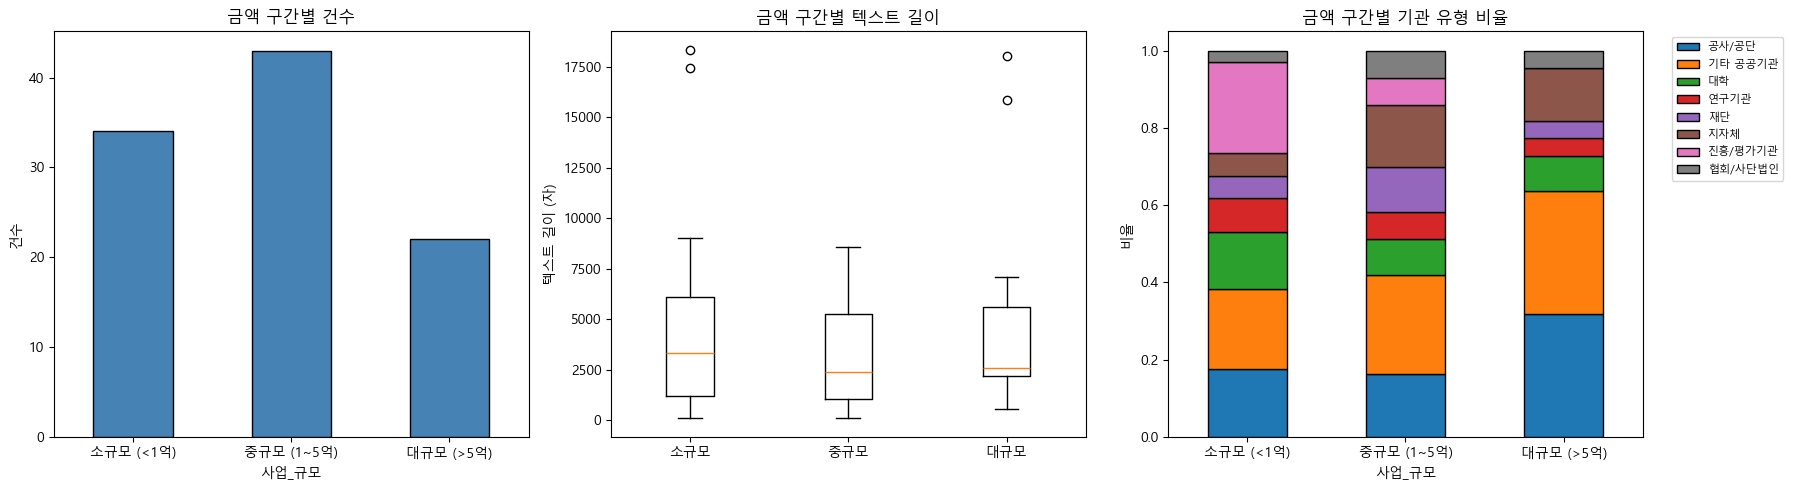

In [19]:
# 4-3. 금액 구간별 사업 특성
scale_bins = [0, 1e8, 5e8, float('inf')]
scale_labels = ['소규모 (<1억)', '중규모 (1~5억)', '대규모 (>5억)']
df['사업_규모'] = pd.cut(df['사업 금액'], bins=scale_bins, labels=scale_labels, right=False)

# 규모별 종합 통계
print("=== 금액 구간별 사업 특성 비교 ===")
scale_stats = df.groupby('사업_규모', observed=False).agg(
    건수=('사업명', 'count'),
    평균금액_억=('사업 금액', lambda x: round(x.mean() / 1e8, 1)),
    평균텍스트길이=('텍스트_길이', lambda x: round(x.mean())),
    평균입찰기간=('입찰_기간', lambda x: round(x.mean(), 1) if x.notna().any() else None)
)
print(scale_stats)

# 규모별 기관 유형 분포
print(f"\n=== 규모별 기관 유형 분포 ===")
cross = pd.crosstab(df['사업_규모'], df['기관_유형'])
print(cross)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 건수
scale_counts = df['사업_규모'].value_counts().sort_index()
scale_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', rot=0)
axes[0].set_ylabel('건수')
axes[0].set_title('금액 구간별 건수')

# 텍스트 길이 비교
data_by_scale = [df[df['사업_규모'] == label]['텍스트_길이'].dropna() for label in scale_labels]
axes[1].boxplot(data_by_scale, labels=['소규모', '중규모', '대규모'])
axes[1].set_ylabel('텍스트 길이 (자)')
axes[1].set_title('금액 구간별 텍스트 길이')

# 기관 유형 비율
cross_pct = cross.div(cross.sum(axis=1), axis=0)
cross_pct.plot(kind='bar', stacked=True, ax=axes[2], edgecolor='black', rot=0)
axes[2].set_ylabel('비율')
axes[2].set_title('금액 구간별 기관 유형 비율')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

---
# EDA 요약 및 RAG 시스템 구축 시사점

## 1단계 결과: 데이터 품질

| 항목 | 결과 | 의미 |
|------|------|------|
| **결측치** | 입찰시작일 26%, 공고번호/차수 18%, 마감일 8%, 금액 1% | 입찰시작일은 결측이 많아 필터 조건으로 사용 시 주의. 공고번호/차수 결측 18건은 동일 패턴(함께 결측)으로 MAR 가능성 |
| **중복** | 사업명 99 unique / 100행, "통합정보시스템 고도화 용역" 1건 중복 | 서로 다른 기관(국가과학기술지식정보서비스 vs 한국한의학연구원)이 동일 사업명 사용. RAG에서는 별개 문서로 취급해야 함 |
| **이상치** | 금액 0원 6건, IQR 이상치 14건 (최대 141억) | 0원 건은 사전공개/입찰공고 단계로 금액 미확정. 금액 필터링 시 0원 제외 로직 필요 |
| **날짜** | 변환 실패 0건, 범위 2021-10 ~ 2025-02 | 날짜 품질 양호. 대부분 2024년 데이터에 집중 |

## 2단계 결과: 기술 통계

| 항목 | 결과 | 의미 |
|------|------|------|
| **금액 분포** | 1억 미만 34건, 1~5억 43건, 5억 이상 22건 (중앙값 1.7억) | 77%가 5억 미만 중소규모 사업. 극심한 우편향(right-skewed) 분포 |
| **발주 기관** | 87개 기관 중 76개가 1건만 발주 | 기관이 극도로 분산되어 있어, 기관명 자체보다 기관 유형으로 그룹핑하는 것이 RAG 필터로 유의미 |
| **입찰 기간** | 평균 9.5일, 중앙값 7일, 0일 6건 존재 | 준비 기간이 짧은 사업이 많음. 0일 건은 데이터 오류 또는 긴급 공고 |

## 3단계 결과: 텍스트 분석 (RAG 핵심)

| 항목 | 결과 | RAG 시사점 |
|------|------|------------|
| **텍스트 길이** | 89~18,335자, 중앙값 2,583자, 1K~3K가 31건으로 최다 | 청킹 사이즈 500~1,000자가 적절. 500자 미만 문서 7건은 청킹 없이 통째로 인덱싱 |
| **텍스트 품질** | 평균 공백비율 37.7%, 연속공백 평균 57.4회, 짧은줄비율 평균 19.1% | **전처리 필수**: 연속공백 정리, 짧은줄(머리글/꼬리글/페이지번호) 제거가 임베딩 품질에 직접 영향 |
| **문서 구조** | 숫자헤더 95%, 로마숫자 85%, 목차패턴 84%, 탭구분자 82% | **섹션 기반 청킹 가능**: 대부분 문서에 구조적 헤더가 존재하므로 "1.", "Ⅰ" 등을 청킹 분할점으로 활용 가능 |
| **문서 유사도** | 평균 0.08, 최대 0.64, 유사도>0.5 단 1쌍 | **중복 문제 낮음**: 문서 간 내용 중복이 거의 없어 별도 dedup 불필요. 검색 결과 다양성 자연 확보 |
| **텍스트 vs 금액** | 피어슨 상관계수 0.03 (원본), -0.09 (로그) | **상관관계 없음**: 사업 규모와 문서 길이는 독립적. 금액 메타데이터를 청킹 전략에 연동할 필요 없음 |

## 4단계 결과: 교차 분석

| 항목 | 결과 | 의미 |
|------|------|------|
| **기관 유형** | 기타공공기관 26건, 공사/공단 20건, 지자체 12건, 대학 11건 | 기관 유형별 평균 금액 차이 큼 (대학·공사 11억 vs 진흥기관 1억). 메타데이터 필터로 활용 가치 있음 |
| **재공고** | 6건 (전체의 7%), 평균 금액 2.7억 vs 초공고 3.9억 | 재공고 건이 적고 뚜렷한 패턴 없음. 별도 처리 불필요 |
| **금액 구간별** | 대규모 사업일수록 입찰기간 길어짐 (소 6.5일 → 대 13.5일) | 사업 규모와 입찰 기간은 양의 관계. 텍스트 길이는 규모와 무관 |

## RAG 구축 핵심 액션 아이템

1. **전처리**: 연속공백 제거, 짧은줄(5자 이하) 필터링, 페이지번호 패턴 제거
2. **청킹 전략**: 숫자 헤더("1.", "2.") / 로마숫자("Ⅰ", "Ⅱ") 기반 섹션 분할 → 500~1,000자 목표
3. **메타데이터 필터**: 기관 유형, 사업 금액 구간, 공개 연도를 검색 필터로 활용
4. **중복 처리**: 문서 간 유사도가 낮아 별도 dedup 불필요
5. **임베딩**: 특수문자 비율이 낮고(평균 0.4%) 한글 품질 양호 → 한국어 임베딩 모델 바로 적용 가능